<a href="https://colab.research.google.com/github/Renju-rl/Git-hub-DSA/blob/main/unsupervised_L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
filepath = '/content/drive/MyDrive/DSA/Data/adult_dataset.csv'
a_d = pd.read_csv(filepath)
a_d.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


#Understand the data

In [6]:
a_d.shape

(48842, 15)

In [7]:
a_d.columns


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [8]:
a_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [9]:
#Replace '?' with NaN
a_d.replace('?', np.nan, inplace=True)


In [10]:
#Check missing values
a_d.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [11]:
#Separate numerical & categorical columns
num_cols = a_d.select_dtypes(include=['int64', 'float64']).columns
cat_cols = a_d.select_dtypes(include=['object']).columns


In [12]:
#Handle Missing Values
for col in num_cols:
    a_d[col].fillna(a_d[col].median(), inplace=True)


/tmp/ipython-input-4211231530.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  a_d[col].fillna(a_d[col].median(), inplace=True)


In [13]:
#Categorical → fill with mode
for col in cat_cols:
    a_d[col].fillna(a_d[col].mode()[0],inplace=True)


/tmp/ipython-input-2015064523.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  a_d[col].fillna(a_d[col].mode()[0],inplace=True)


In [14]:
a_d.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


##Detect Outliers (Visualization)

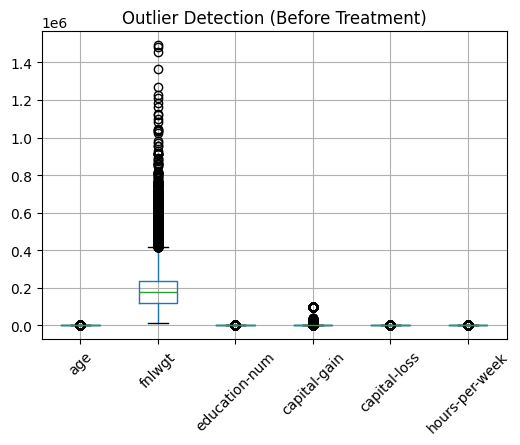

In [15]:
a_d[num_cols].boxplot(rot=45, figsize=(6,4))
plt.title("Outlier Detection (Before Treatment)")
plt.show()


##Treat Outliers

In [16]:
for col in num_cols:
    Q1 = a_d[col].quantile(0.25)
    Q3 = a_d[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    a_d[col] = a_d[col].clip(lower, upper)


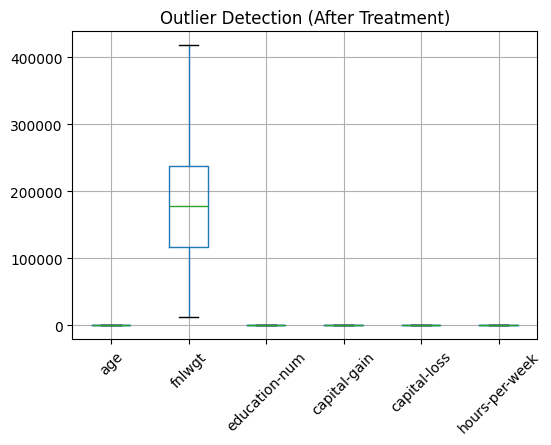

In [17]:
a_d[num_cols].boxplot(rot=45, figsize=(6,4))
plt.title("Outlier Detection (After Treatment)")
plt.show()


##Encode Categorical Variables

In [18]:
a_d_encoded = pd.get_dummies(a_d, drop_first=True)


##Feature Scaling

In [19]:
scaler = StandardScaler()
a_d_encoded[num_cols] = scaler.fit_transform(a_d_encoded[num_cols])
a_d_encoded=a_d_encoded.astype(int)

In [20]:
a_d_encoded.head()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K.,income_>50K,income_>50K.
0,0,-1,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,-1,1,0,0,-1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
3,1,0,-1,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
a_d_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 100 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        48842 non-null  int64
 1   fnlwgt                                     48842 non-null  int64
 2   education-num                              48842 non-null  int64
 3   capital-gain                               48842 non-null  int64
 4   capital-loss                               48842 non-null  int64
 5   hours-per-week                             48842 non-null  int64
 6   workclass_Local-gov                        48842 non-null  int64
 7   workclass_Never-worked                     48842 non-null  int64
 8   workclass_Private                          48842 non-null  int64
 9   workclass_Self-emp-inc                     48842 non-null  int64
 10  workclass_Self-emp-not-inc                 48

#Prepare data for PCA

In [22]:
X = a_d_encoded.values

##Apply PCA

In [23]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X)


##Explained Variance Plot

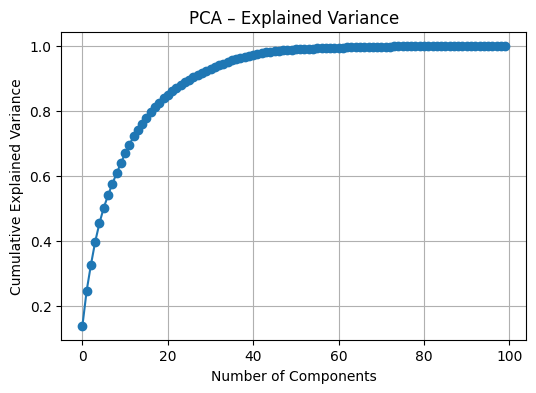

In [24]:
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(6,4))
plt.plot(cum_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Explained Variance')
plt.grid()
plt.show()

##Apply PCA with 95% variance

In [25]:
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X)


In [26]:
X_pca_95.shape

(48842, 35)

##Convert PCA output to DataFrame

In [27]:
pca_cols = [f'PC{i+1}' for i in range(X_pca_95.shape[1])]

a_d_pca = pd.DataFrame(X_pca_95, columns=pca_cols)


#2 Exploratory Analysis

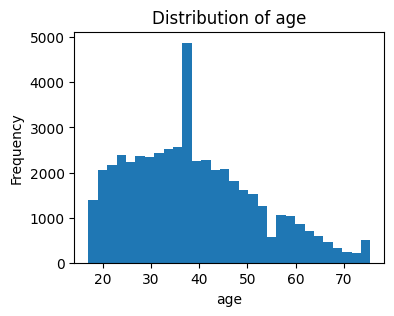

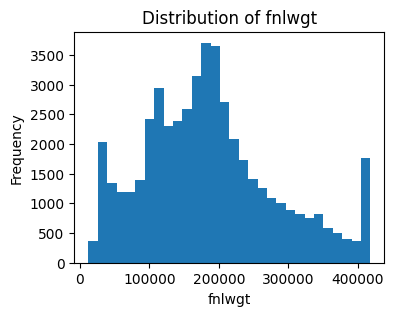

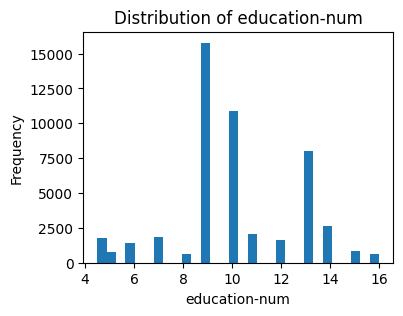

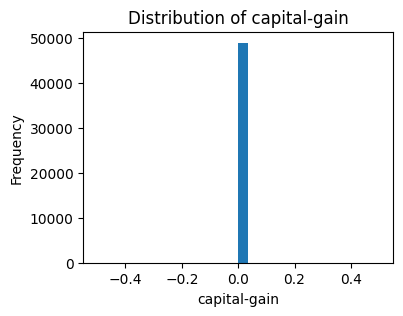

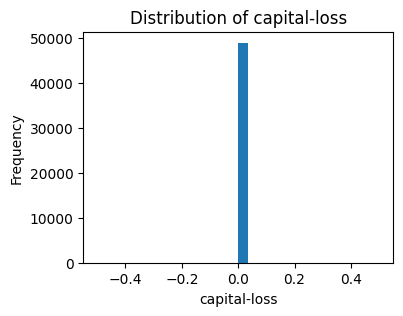

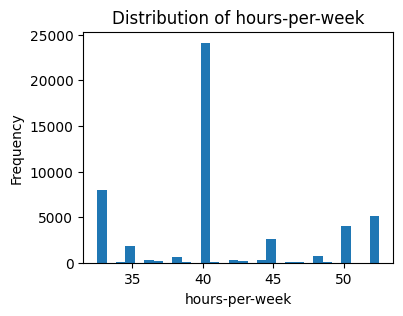

In [28]:
#Visualize Feature Distributions

#Code (Numerical Features)
import matplotlib.pyplot as plt

num_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']

for col in num_cols:
    plt.figure(figsize=(4,3))
    plt.hist(a_d[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


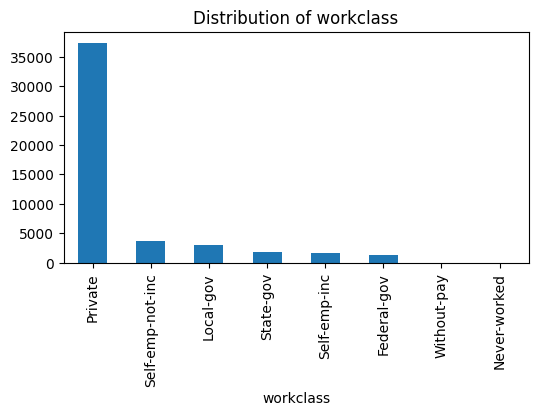

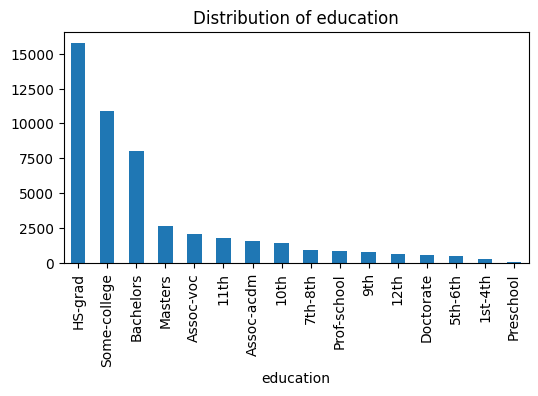

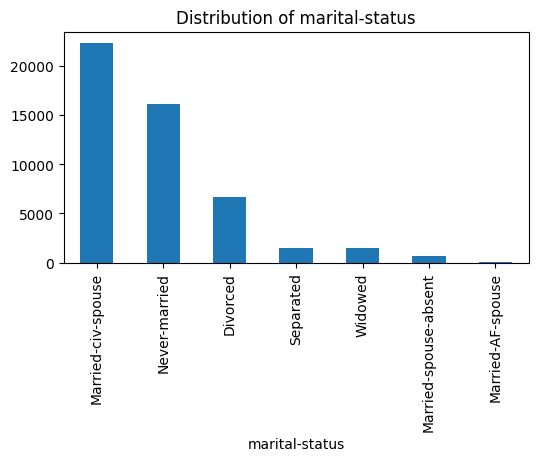

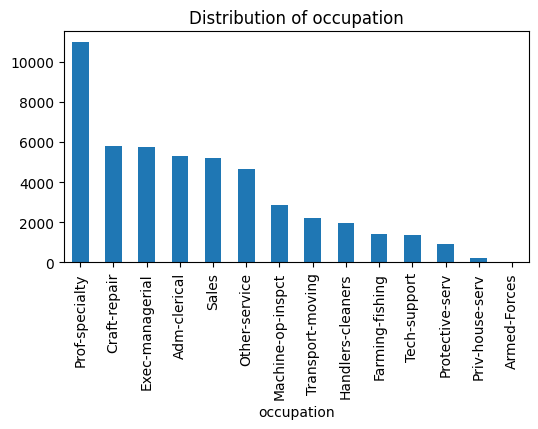

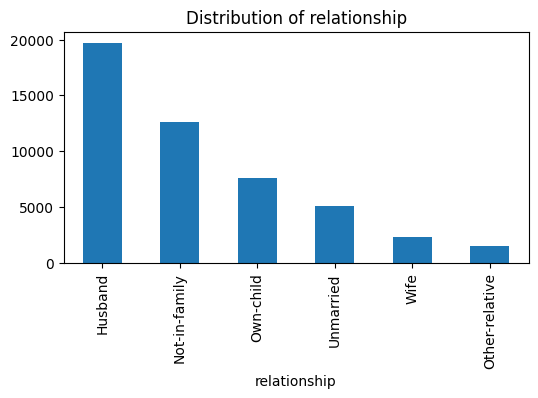

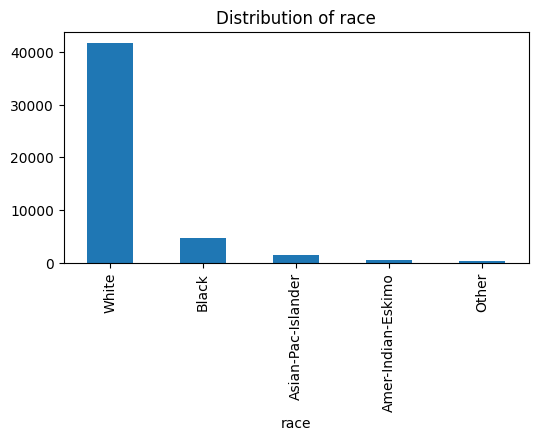

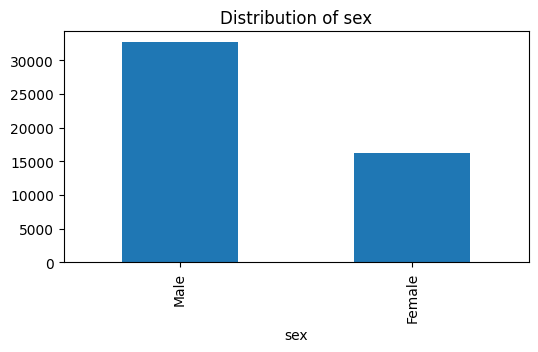

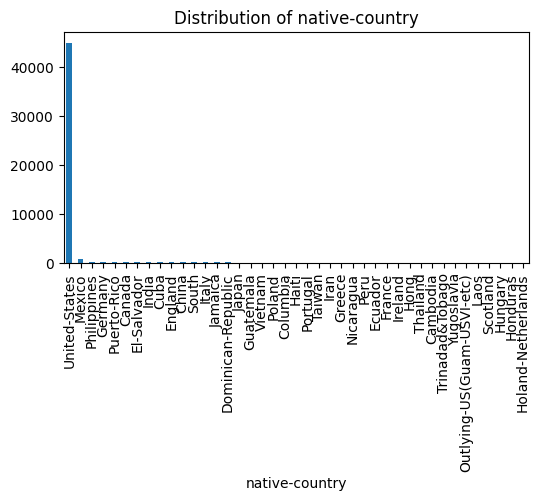

In [29]:
#Code (Categorical Features)
cat_cols = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']

for col in cat_cols:
    plt.figure(figsize=(6,3))
    a_d[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.show()


##Analyze Correlations Between Variables

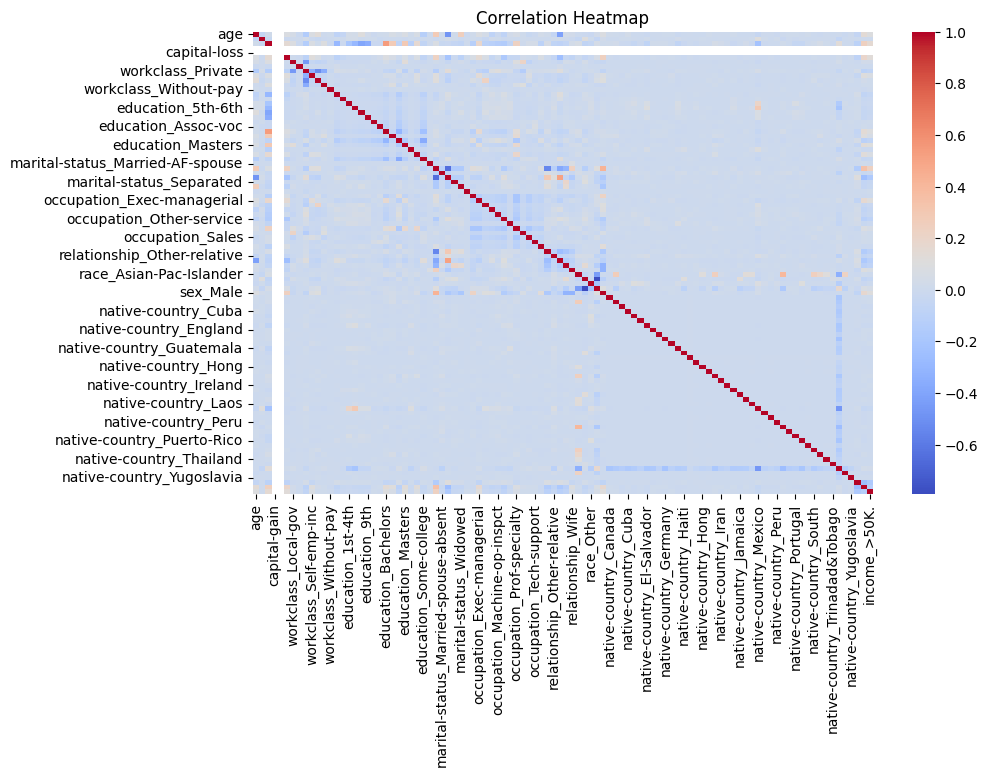

In [30]:
#Code: Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(10,6))
corr = a_d_encoded.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [31]:
#Dimensionality Reduction for Visualization (PCA)
#PCA (2 Components)

from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(a_d_encoded)


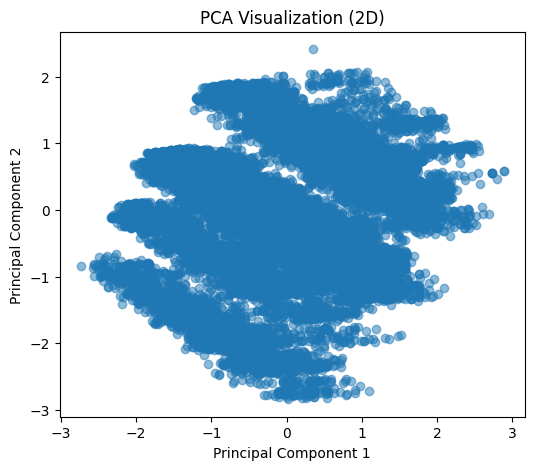

In [32]:
#PCA Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization (2D)')
plt.show()


##(Optional) t-SNE Visualization

In [33]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(a_d_encoded.sample(3000))  # sampling for speed


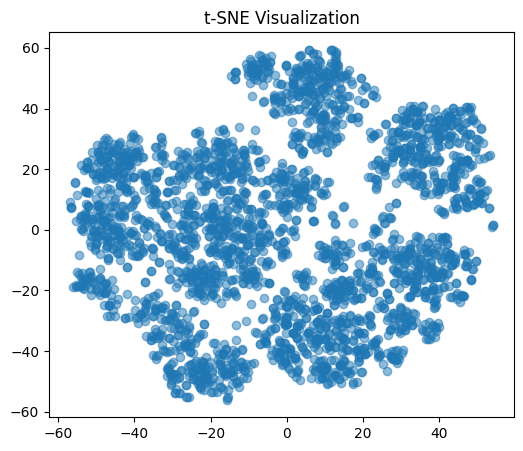

In [34]:
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.5)
plt.title("t-SNE Visualization")
plt.show()


#3 Clustering

In [35]:
a_d_encoded   # cleaned, encoded, scaled


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K.,income_>50K,income_>50K.
0,0,-1,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,-1,1,0,0,-1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
3,1,0,-1,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
48838,1,1,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
48839,0,1,1,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
48840,0,-1,1,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0


In [36]:
#Reduce data to 2D using PCA

from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(a_d_encoded)


In [37]:
#KMeans – Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca_2)
    inertia.append(kmeans.inertia_)


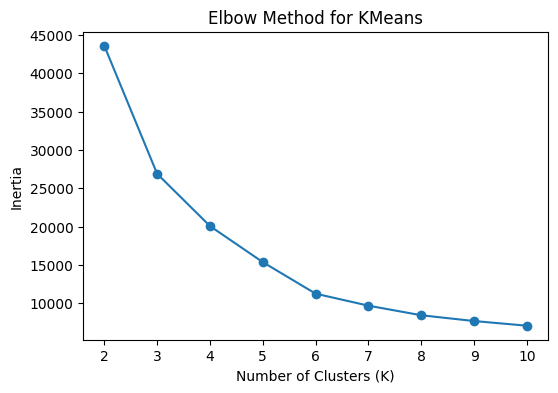

In [38]:
#Plot Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans')
plt.show()


###Silhouette Score (confirm K)

In [44]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca_2)
    score = silhouette_score(X_pca_2, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.382
K=3, Silhouette Score=0.446
K=4, Silhouette Score=0.467
K=5, Silhouette Score=0.485
K=6, Silhouette Score=0.482


In [40]:
#Apply Final KMeans Model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca_2)


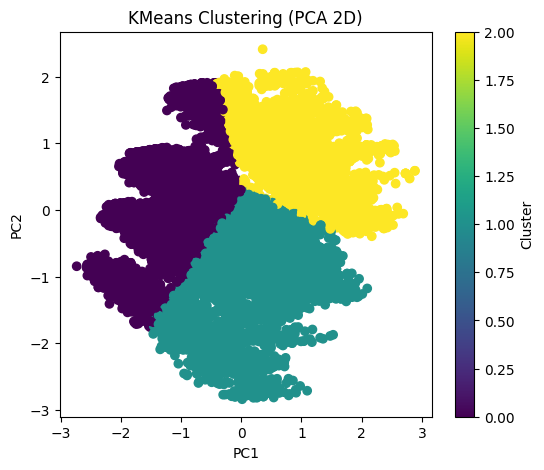

In [41]:
#Visualize KMeans Clusters
plt.figure(figsize=(6,5))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=kmeans_labels, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clustering (PCA 2D)')
plt.colorbar(label='Cluster')
plt.show()


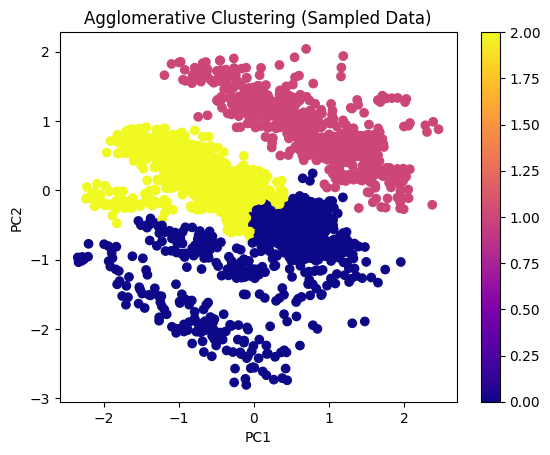

In [42]:
#Agglomerative (Hierarchical) Clustering
# Sampling to avoid memory crash
sample_size = 3000
idx = np.random.choice(len(X_pca_2), sample_size, replace=False)
X_sample = X_pca_2[idx]

# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_sample)

# Visualization
plt.scatter(X_sample[:,0], X_sample[:,1], c=labels, cmap='plasma')
plt.title('Agglomerative Clustering (Sampled Data)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.show()


###dendrogram

In [43]:
#not needed
import numpy as np

sample_size = 1000   # keep ≤ 1000 for dendrogram
idx = np.random.choice(len(X_pca_2), sample_size, replace=False)
X_sample = X_pca_2[idx]


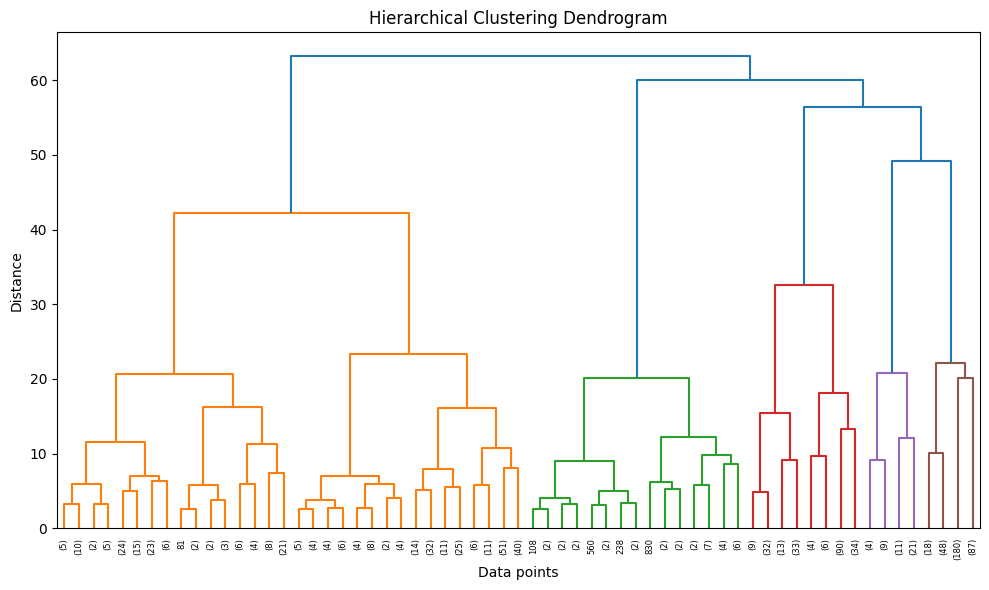

In [55]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Sample data (avoid crash)
X_sample = X[np.random.choice(X.shape[0], 1000, replace=False)]

# 2. Scale data
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# 3. PCA (recommended)
pca = PCA(n_components=5, random_state=42)
X_reduced = pca.fit_transform(X_sample_scaled)

# 4. Hierarchical clustering
Z = linkage(X_reduced, method='ward')

# 5. Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


#4 Interpretation & Profiling

In [56]:
#Add Cluster Labels Back to Dataset
a_d_clustered = a_d.copy()
a_d_clustered['Cluster'] = kmeans_labels


In [57]:
#Cluster Size Distribution
a_d_clustered['Cluster'].value_counts()

,count
Cluster,
1,21002
0,16776
2,11064


In [58]:
#Demographic & Work Profile (Numerical)
num_cols = ['age','education-num','hours-per-week','capital-gain','capital-loss']

cluster_profile_num = a_d_clustered.groupby('Cluster')[num_cols].mean()
cluster_profile_num


,age,education-num,hours-per-week,capital-gain,capital-loss
Cluster,,,,,
0,28.572008,9.407576,38.243503,0.0,0.0
1,44.705528,8.898605,42.179626,0.0,0.0
2,41.912554,13.527928,43.512880,0.0,0.0


In [59]:
#Categorical Profile per Cluster
cat_cols = ['workclass','education','marital-status','occupation','sex']

for col in cat_cols:
    print("\n", col.upper())
    print(a_d_clustered.groupby('Cluster')[col].agg(lambda x: x.value_counts().index[0]))



 WORKCLASS
Cluster
0    Private
1    Private
2    Private
Name: workclass, dtype: object

 EDUCATION
Cluster
0      HS-grad
1      HS-grad
2    Bachelors
Name: education, dtype: object

 MARITAL-STATUS
Cluster
0         Never-married
1    Married-civ-spouse
2    Married-civ-spouse
Name: marital-status, dtype: object

 OCCUPATION
Cluster
0    Prof-specialty
1      Craft-repair
2    Prof-specialty
Name: occupation, dtype: object

 SEX
Cluster
0    Female
1      Male
2      Male
Name: sex, dtype: object


In [60]:
#Compare Clusters with Income (NOT used in training)
pd.crosstab(a_d_clustered['Cluster'], a_d_clustered['income'], normalize='index')


income,<=50K,<=50K.,>50K,>50K.
Cluster,,,,
0,0.641452,0.344659,0.008703,0.005186
1,0.496143,0.235787,0.179792,0.088277
2,0.319866,0.153742,0.354212,0.172180


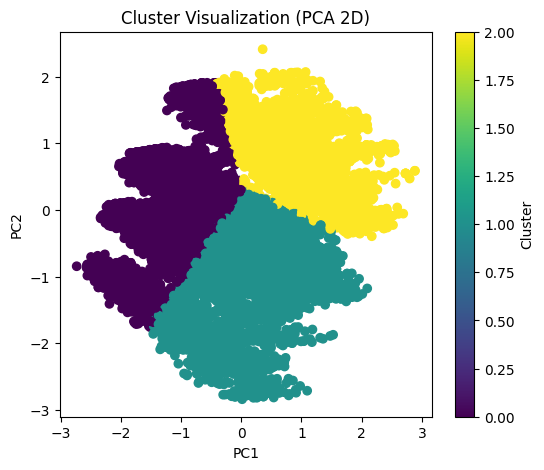

In [61]:
#Visual Cluster Interpretation (2D)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=kmeans_labels, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cluster Visualization (PCA 2D)')
plt.colorbar(label='Cluster')
plt.show()
